## Build A Basic Chatbot With Langgraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages    # Reducers

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotated defines how the state key should be updated 
    # (in this case, it appends messages to the list, rather then overwrite them)
    messages:Annotated[list, add_messages]



In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

In [6]:
## Node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)
## adding edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

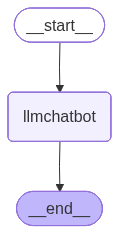

In [8]:
## visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"Hi"})

In [10]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here to help you with any questions or tasks you may have. How can I assist you today?


### Chatbot with Tools

In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [12]:
## Custom Function
def multiply(a:int, b:int) -> int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
        
    Returns:
        int: output int
    """
    return a * b

In [13]:
tools = [tool, multiply]

In [14]:
llm_with_tool = llm.bind_tools(tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014F317F6AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014F3195EF90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

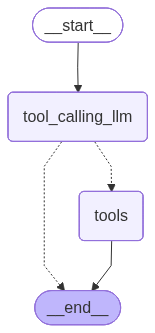

In [16]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state : State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest msg (result) from assistant is a tool call -> tools_condition route to tools.
    # If the latest msg (result) from assistant is not a tool call -> tools_condition route to END.
    tools_condition
)
builder.add_edge("tools", END)


## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
response = graph.invoke({"messages":"What is the recent AI news"})


In [18]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fintechfutures.com/ai-in-fintech/may-2026-top-five-ai-stories-of-the-month", "title": "May 2026: Top five AI stories of the month - FinTech Futures", "score": 0.7813477, "published_date": "Fri, 29 May 2026 12:49:48 GMT", "content": "BNP Paribas has extended its existing contract with Microsoft-backed start-up \\n\\nMistral AI\\n by three years, with a focus on designing and deploying generative AI solutions across the group\'s corporate and institutional banking (CIB) and commercial personal banking and services (CPBS) divisions, and later extending to the rest of the group.\\n\\nThe Paris-headquartered banking group \\n\\nfirst started implementing Mistral AI\'s commercial models\\n across its business lines in July 2024. Current applications span document handling, data management, onboarding, and client and employee chatbot services.\\n\\nNow the collaboration is 

In [19]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1n38m2nqw)
 Call ID: 1n38m2nqw
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fintechfutures.com/ai-in-fintech/may-2026-top-five-ai-stories-of-the-month", "title": "May 2026: Top five AI stories of the month - FinTech Futures", "score": 0.7813477, "published_date": "Fri, 29 May 2026 12:49:48 GMT", "content": "BNP Paribas has extended its existing contract with Microsoft-backed start-up \n\nMistral AI\n by three years, with a focus on designing and deploying generative AI solutions across the group's co

In [20]:
response = graph.invoke({"messages":"What is 2 multiplied by 5"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5
================================== Ai Message ==================================
Tool Calls:
  multiply (4dr4qjd13)
 Call ID: 4dr4qjd13
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10


In [21]:
response = graph.invoke({"messages":"What is 2 multiplied by 5 and then multiply 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and then multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (ydwwwjrt3)
 Call ID: ydwwwjrt3
  Args:
    a: 2
    b: 5
  multiply (kqeq4h0m8)
 Call ID: kqeq4h0m8
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

100


### ReAct Agent Architecture

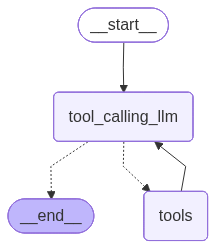

In [22]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state : State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest msg (result) from assistant is a tool call -> tools_condition route to tools.
    # If the latest msg (result) from assistant is not a tool call -> tools_condition route to END.
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")


## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({"messages": "Give me the AI news and Multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the AI news and Multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nfyvx446c)
 Call ID: nfyvx446c
  Args:
    query: AI news
    topic: news
  multiply (yzhb15xx6)
 Call ID: yzhb15xx6
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mobihealthnews.com/video/deregulation-enables-ai-innovation-adds-liability-risk", "title": "Deregulation enables AI innovation, but adds liability risk - MobiHealthNews", "score": 0.5689194, "published_date": "Thu, 11 Jun 2026 15:00:00 GMT", "content": "# Deregulation enables AI innovation, but adds liability risk. As AI regulations loosen, Ben Scharfe, Altera Digital Health EVP of artificial intelligence

### Adding Memory in the Agentic Graph

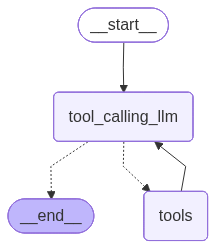

In [25]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state : State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest msg (result) from assistant is a tool call -> tools_condition route to tools.
    # If the latest msg (result) from assistant is not a tool call -> tools_condition route to END.
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")


## Compile the graph
graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
### Thread ID for a perticular conversation (should be unique)
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages": "Hi my name is Achyut"}, config = config)

response


{'messages': [HumanMessage(content='Hi my name is Achyut', additional_kwargs={}, response_metadata={}, id='22eb67c7-b92e-41f6-97b5-1516572dead5'),
  AIMessage(content='Hello Achyut, how are you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 1752, 'total_tokens': 1763, 'completion_time': 0.032214574, 'completion_tokens_details': None, 'prompt_time': 0.127076996, 'prompt_tokens_details': None, 'queue_time': 0.159623894, 'total_time': 0.15929157}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbee-f6cb-79c1-9065-70d2b2dd4e5b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 11, 'total_tokens': 1763}),
  HumanMessage(content='Hi my name is Achyut', additional_kwargs={}, response_metadata={}, id='4e150410-0dc2-4ad1-8f8e-301bfbf705fd'),
  AIM

In [31]:
response['messages'][-1].content

"It's nice to meet you, Achyut. Is there something I can help you with or would you like to chat?"

In [34]:
response = graph.invoke({"messages":"What is my Name?"}, config = config)
print(response['messages'][-1].content)

Achyut


In [36]:
response = graph.invoke({"messages":"Hey do you remember my name?"}, config = config)
print(response['messages'][-1].content)

Your name is Achyut.


### Streaming

In [37]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [38]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

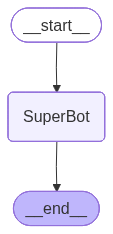

In [39]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer = memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [40]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi, My name is Achyut and I like cricket"}, config = config)

{'messages': [HumanMessage(content='Hi, My name is Achyut and I like cricket', additional_kwargs={}, response_metadata={}, id='1fc9645a-ad42-4c59-89fd-cdefb7994780'),
  AIMessage(content='Nice to meet you, Achyut. Cricket is a fantastic sport, with a huge following across the globe. Which team or player do you support? Are you a fan of Test cricket, One-Day Internationals (ODIs), or the shorter format of the game, Twenty20 (T20)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 47, 'total_tokens': 110, 'completion_time': 0.106000382, 'completion_tokens_details': None, 'prompt_time': 0.002651532, 'prompt_tokens_details': None, 'queue_time': 0.159240988, 'total_time': 0.108651914}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecc27-7b2d-7b42-adfe-027072b7ba6d-0', tool_calls=[], invalid_tool_ca

### Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state


- **values** : This streams the full state of the graph after each node is called. (It appends the each node in dict)
- **updates** : This streams updates to the state of the graph after each node is called. (It does now append)

In [41]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages': "Hi, My name is Achyut and I like cricket"}, config, stream_mode = "updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Achyut. Cricket is a great sport, isn't it? There's something about the thrill of watching a batsman hit a six or a bowler taking a wicket that's just so captivating. Do you have a favorite team or player that you follow?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 47, 'total_tokens': 107, 'completion_time': 0.102495921, 'completion_tokens_details': None, 'prompt_time': 0.486323251, 'prompt_tokens_details': None, 'queue_time': 0.423107939, 'total_time': 0.588819172}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecc35-3856-7901-af94-d32e65c2bb4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 60, 'total_tokens': 107})]}}


In [42]:
for chunk in graph_builder.stream({'messages': "Hi, My name is Achyut and I like cricket"}, config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Achyut and I like cricket', additional_kwargs={}, response_metadata={}, id='054d1dd8-d1a8-4fe4-b16c-0d193383efcf'), AIMessage(content="Nice to meet you, Achyut. Cricket is a great sport, isn't it? There's something about the thrill of watching a batsman hit a six or a bowler taking a wicket that's just so captivating. Do you have a favorite team or player that you follow?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 47, 'total_tokens': 107, 'completion_time': 0.102495921, 'completion_tokens_details': None, 'prompt_time': 0.486323251, 'prompt_tokens_details': None, 'queue_time': 0.423107939, 'total_time': 0.588819172}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecc35-3856-7901-af94-d32e65c2bb4e-0', tool_calls=[], invalid_tool_calls=[], 